# $Z_3$ greedy campaign --- plot everything (physical vs PRS)

N=1024 "greedy" runs, $\beta\in\{0.01,0.1,0.3,0.7,0.9\}$, 3 seeds, paired
physical$\leftrightarrow$PRS (common random numbers).  Physical $\mu=H_0=0.07$
(each $\beta$ in its own box, adjacent wall $\to$ 2 cells at $a_{\max}$); PRS
$\mu=H_0=1$ (fixed box).  Runs are live --- loaders tolerate short/missing files;
safe to re-run as output accumulates.

**Conventions.** Every figure $\le2$ panels, one quantity each; busy quantities are
split into the two physical regimes $\beta\le1/3$ (adjacent-dominated) and
$\beta>1/3$ (opposite walls bound).  Colour $=\beta$ (Okabe-Ito), **physical solid /
PRS dashed**, $\pm1\sigma$ seed band.

In [1]:
import os, numpy as np, matplotlib.pyplot as plt
from matplotlib import rc
from matplotlib.lines import Line2D

USETEX = True
try:
    rc('text', usetex=USETEX)
    rc('font', **{'family': 'serif', 'serif': ['Computer Modern Roman'], 'size': 13})
except Exception:
    USETEX = False
rc('axes', linewidth=0.8)
rc('mathtext', fontset='cm')
np.seterr(divide='ignore', invalid='ignore')

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

In [2]:
REPO  = '/mt/home/dpasari/CosmoLattice_Zn'
BASE  = os.path.join(REPO, 'results')
MODEL = 'Z3'; TAG = 'DWZ3'; ZN = 3; NWALL = 1
SCAN  = {'phys': 'scan_z3_phys_greedy', 'prs': 'scan_z3_prs_greedy'}
BTAG  = '30'

BETAS = [0.01, 0.1, 0.3, 0.7, 0.9]
BLAB  = {0.01: '01', 0.1: '1', 0.3: '3', 0.7: '7', 0.9: '9'}
SEEDS = ['s01', 's02', 's03']
DADJ  = {0.01: 9.0, 0.1: 2.657, 0.3: 1.55, 0.7: 1.059, 0.9: 0.843}                       # adjacent (headline) wall width (mu=1 BVP)

EVOS   = ['phys', 'prs']
LS     = {'phys': '-', 'prs': '--'}
EVOLAB = {'phys': 'physical', 'prs': 'PRS'}
LW     = 1.7

# user-preferred qualitative palette (purple / teal-green / orange / magenta / steel-blue)
BCOL   = {0.01: '#482878', 0.1: '#35B377', 0.3: '#E8A33D', 0.7: '#C0398A', 0.9: '#4878A8'}

# physical-regime split (1/3 = opposite walls become bound)
LOWB   = [b for b in BETAS if b <= 1.0/3.0]      # 0.01, 0.1, 0.3
HIGHB  = [b for b in BETAS if b >  1.0/3.0]       # 0.7, 0.9
GROUPS = [(r'$\beta \le 1/3$', LOWB), (r'$\beta > 1/3$', HIGHB)]
REPB   = [0.1, 0.9]                               # representative low / high beta

ARCHIVE = os.path.join(REPO, 'results_archive', 'prebinningfix_2026-06-27')

def run_dir(beta, evo, seed):
    name = f'results_{TAG}_greedy_b{BTAG}p{BLAB[beta]}_{seed}'
    if evo == 'prs':
        # preference: extended long (eta<=120) -> results/ short -> archived short (eta<=50)
        for cand in (os.path.join(BASE, SCAN['prs'] + '_long', name),
                     os.path.join(BASE, SCAN['prs'], name),
                     os.path.join(ARCHIVE, SCAN['prs'], name)):
            if os.path.exists(os.path.join(cand, 'average_energies.txt')):
                return cand
    return os.path.join(BASE, SCAN[evo], name)

def path_src(p):
    if not p:                          return '--'
    if '_prs_greedy_long' in p:        return 'PRS-long'
    if 'results_archive' in p:         return 'PRS-arch(<=50)'
    if '_prs_greedy' in p:             return 'PRS-short'
    if '_phys_greedy' in p:            return 'phys'
    return '?'

## Loaders & parameters

Two real fields $h=$`scalar_0`, $a=$`scalar_1`, $\Phi=(h+ia)/\sqrt2$.
- `average_energies.txt`: `eta, Ek_h, Eg_h, Ek_a, Eg_a, V0, V1, V2, Etot, scal1[, scal2]`
  --- $\mathcal{A}_k=\mathrm{scal}_k/(2aH)$.
- `average_scalar_i.txt`: `eta, <f>, <f'>, <f^2>, <f'^2>, rms`.
- `average_scale_factor.txt`: `eta, a, a', H`.
- `average_wall_diagnostics.txt`: junction-string + wall-velocity sums (infrequent).
- run parameters parsed from `*.infos`.

In [3]:
def _safe(fpath, minc):
    # tolerant of LIVE files: a partial last line is dropped, not fatal.
    try:
        if not os.path.exists(fpath) or os.path.getsize(fpath) == 0:
            return None
        rows = []
        for line in open(fpath):
            t = line.split()
            if len(t) < minc:
                continue
            try:
                rows.append([float(x) for x in t])
            except ValueError:
                continue
        if not rows:
            return None
        ncol = min(len(r) for r in rows)
        d = np.array([r[:ncol] for r in rows], float)
    except OSError:
        return None
    if d.ndim == 1:
        d = d[np.newaxis, :]
    return d if d.shape[1] >= minc else None

WD_COLS = ['Jstr_len', 'Jstr_cnt', 'Jstr_signed', 'Jstr_w2', 'Jcore_cnt', 'velA02_KE', 'velA02_V', 'velA02_N', 'velA04_KE', 'velA04_V', 'velA04_N', 'velA06_KE', 'velA06_V', 'velA06_N', 'velBadj_KE', 'velBadj_V', 'velBadj_N']

def parse_infos(path):
    f = os.path.join(path, TAG + '.infos'); p = {}
    if not os.path.exists(f):
        return p
    for line in open(f):
        t = line.split()
        if len(t) >= 2:
            try:
                p[t[0]] = float(t[1])
            except ValueError:
                p[t[0]] = t[1]
    return p

def load_energies(path):
    d = _safe(os.path.join(path, 'average_energies.txt'), 10)
    if d is None:
        return None
    out = dict(eta=d[:, 0], Ek_h=d[:, 1], Eg_h=d[:, 2], Ek_a=d[:, 3], Eg_a=d[:, 4],
               V0=d[:, 5], V1=d[:, 6], V2=d[:, 7], Etot=d[:, 8], scal1=d[:, 9])
    out['scal2'] = None
    return out

def load_scalar(path, i):
    d = _safe(os.path.join(path, f'average_scalar_{i}.txt'), 6)
    return None if d is None else dict(eta=d[:, 0], mean=d[:, 1], mean_p=d[:, 2],
                                       mean2=d[:, 3], mean_p2=d[:, 4], rms=d[:, 5])

def load_sf(path):
    d = _safe(os.path.join(path, 'average_scale_factor.txt'), 4)
    return None if d is None else dict(eta=d[:, 0], a=d[:, 1], ap=d[:, 2], H=d[:, 3])

def load_wd(path):
    d = _safe(os.path.join(path, 'average_wall_diagnostics.txt'), 1 + len(WD_COLS))
    if d is None:
        return None
    wd = {'eta': d[:, 0]}; wd.update({c: d[:, i + 1] for i, c in enumerate(WD_COLS)})
    return wd

def load_spectra(path, i=0):
    f = os.path.join(path, f'spectra_scalar_{i}.txt')
    if not os.path.exists(f):
        return None
    blocks, cur = [], []
    for line in open(f):
        if line.strip() == '':
            if cur:
                blocks.append(np.array(cur)); cur = []
        else:
            try:
                cur.append([float(x) for x in line.split()])
            except ValueError:
                pass
    if cur:
        blocks.append(np.array(cur))
    t = _safe(os.path.join(path, 'average_spectra_times.txt'), 1)
    return dict(times=t.ravel() if t is not None else np.arange(len(blocks)), blocks=blocks)

def load_one(beta, evo, seed):
    p = run_dir(beta, evo, seed)
    en, sf = load_energies(p), load_sf(p)
    if en is None or sf is None:
        return None
    return dict(energies=en, scale_factor=sf, scalar0=load_scalar(p, 0), scalar1=load_scalar(p, 1),
                wall_diag=load_wd(p), spectra=load_spectra(p), infos=parse_infos(p),
                evo=evo, beta=beta, path=p)

DATA = {b: {e: {} for e in EVOS} for b in BETAS}
print(f"{'beta':>6} {'evo':>5} {'seed':>5} {'eta_max':>8} {'wd':>4}"); print('-'*34)
for b in BETAS:
    for e in EVOS:
        for sd in SEEDS:
            d = load_one(b, e, sd); DATA[b][e][sd] = d
            if d is None:
                print(f"{b:>6} {e:>5} {sd:>5} {'--':>8}")
            else:
                wd = 0 if d['wall_diag'] is None else len(d['wall_diag']['eta'])
                print(f"{b:>6} {e:>5} {sd:>5} {d['energies']['eta'][-1]:>8.2f} {wd:>4}")

  beta   evo  seed  eta_max   wd
----------------------------------
  0.01  phys   s01   180.36   37


  0.01  phys   s02   180.36   37
  0.01  phys   s03   180.36   37
  0.01   prs   s01   119.90   24


  0.01   prs   s02   119.90   24
  0.01   prs   s03   119.90   24
   0.1  phys   s01    97.50   20
   0.1  phys   s02    97.50   20


   0.1  phys   s03    97.50   20
   0.1   prs   s01   119.90   24
   0.1   prs   s02   119.90   24
   0.1   prs   s03   119.90   24


   0.3  phys   s01    74.20   15
   0.3  phys   s02    74.20   15
   0.3  phys   s03    74.20   15
   0.3   prs   s01   119.90   24


   0.3   prs   s02   119.90   24
   0.3   prs   s03   119.90   24
   0.7  phys   s01    61.16   13
   0.7  phys   s02    61.16   13
   0.7  phys   s03    61.16   13


   0.7   prs   s01   119.90   24
   0.7   prs   s02   119.90   24
   0.7   prs   s03   119.90   24
   0.9  phys   s01    54.46   11


   0.9  phys   s02    54.46   11
   0.9  phys   s03    54.46   11
   0.9   prs   s01   119.90   24
   0.9   prs   s02   119.90   24


   0.9   prs   s03   119.90   24


## Helpers (physics + plotting)

In [4]:
def _ip(d, x, key):
    sf = d['scale_factor']; return np.interp(x, sf['eta'], sf[key])

def area_seed(d, which='scal1'):
    en = d['energies']
    if en.get(which) is None:
        return en['eta'], np.full_like(en['eta'], np.nan)
    # Z3 archived (pre-binning-fix) PRS has corrupt scal1/scal2 -> drop; velA/junction stay valid
    if MODEL == 'Z3' and 'results_archive' in d.get('path', ''):
        return en['eta'], np.full_like(en['eta'], np.nan)
    a = _ip(d, en['eta'], 'a'); H = _ip(d, en['eta'], 'H')
    return en['eta'], en[which] / (2.0 * a * H)

def slope_seed(d, which='scal1'):
    return log_slope(*area_seed(d, which))

def xi_seed(d):
    wd = d['wall_diag']
    if wd is None:
        return np.array([]), np.array([])
    a = _ip(d, wd['eta'], 'a'); H = _ip(d, wd['eta'], 'H')
    return wd['eta'], wd['Jstr_len'] / (2.0 * a * H**2)

def wdcol(col):
    return lambda d: ((d['wall_diag']['eta'], d['wall_diag'][col])
                      if d['wall_diag'] is not None else (np.array([]), np.array([])))

def v2g2_seed(d, cut='A04'):
    wd = d['wall_diag']
    if wd is None:
        return np.array([]), np.array([])
    vg = wd[f'vel{cut}_KE'] / wd[f'vel{cut}_V']
    if d['evo'] == 'prs':
        vg = vg * _ip(d, wd['eta'], 'a')**2          # conformal-time (PRS only)
    return wd['eta'], vg

def v2_seed(d, cut='A04'):
    x, vg = v2g2_seed(d, cut); return x, vg / (1.0 + vg)

def _vev_z3(l1, l2, mu):
    return mu * (3*l2 + np.sqrt(8*l1 + 9*l2**2)) / (2*np.sqrt(2.0)*l1)

def m_h(d):
    inf = d['infos']; mu = inf.get('mu', 1.0)
    lambda1 = inf.get('lambda1', 1.0); lambda2 = inf.get('lambda2', 0.0)
    return (lambda l1, l2, mu: np.sqrt(max(-mu**2 + 3*l1*_vev_z3(l1, l2, mu)**2 - 3*np.sqrt(2.0)*l2*mu*_vev_z3(l1, l2, mu), 1e-12)))(lambda1, lambda2, mu)

def cells_per_wall(d):
    inf = d['infos']; sf = d['scale_factor']
    mu = inf.get('mu', 1.0); dx = inf.get('lSide', 1.0)/inf.get('N', 1024)
    a = sf['a'] if d['evo'] == 'phys' else np.ones_like(sf['a'])
    return sf['eta'], DADJ[d['beta']] / (mu * a * dx)

def cells_per_core(d):
    inf = d['infos']; sf = d['scale_factor']; dx = inf.get('lSide', 1.0)/inf.get('N', 1024)
    a = sf['a'] if d['evo'] == 'phys' else np.ones_like(sf['a'])
    return sf['eta'], (2.0 / m_h(d)) / (a * dx)

def seed_stack(beta, evo, fn):
    xref, ys = None, []
    for sd in SEEDS:
        d = DATA[beta][evo][sd]
        if d is None:
            continue
        x, y = fn(d)
        if x is None or len(x) == 0:
            continue
        if xref is None:
            xref = np.asarray(x)
        ys.append(np.interp(xref, x, y))
    if not ys:
        return None, None, None
    Y = np.vstack(ys); return xref, np.nanmean(Y, 0), np.nanstd(Y, 0)

def first_run(beta, evo):
    return next((DATA[beta][evo][s] for s in SEEDS if DATA[beta][evo][s] is not None), None)

# ---- plotting primitives ----
def paper_ax(ax, xlabel=r'$\eta$', ylabel='', title=''):
    if xlabel: ax.set_xlabel(xlabel, fontsize=14)
    if ylabel: ax.set_ylabel(ylabel, fontsize=14)
    if title:  ax.set_title(title, fontsize=12.5)
    ax.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=11)
    ax.minorticks_on(); ax.grid(True, ls='-', lw=0.3, alpha=0.15)

def band(ax, x, m, sd, color, ls):
    ax.plot(x, m, color=color, ls=ls, lw=LW, zorder=3, solid_capstyle='round')
    if sd is not None:
        ax.fill_between(x, m - sd, m + sd, color=color, alpha=0.12, lw=0, zorder=1)

def plot_betas(ax, betas, fn, std=True):
    for b in betas:
        for e in EVOS:
            x, m, sd = seed_stack(b, e, fn)
            if x is not None and len(x):
                band(ax, x, m, sd if std else None, BCOL[b], LS[e])

def beta_legend(ax, betas, loc='best', fs=10):
    h = [Line2D([0], [0], color=BCOL[b], lw=2.4, label=rf'$\beta={b}$') for b in betas]
    h += [Line2D([0], [0], color='0.35', lw=1.8, ls='-', label='phys'),
          Line2D([0], [0], color='0.35', lw=1.8, ls='--', label='PRS')]
    ax.legend(handles=h, fontsize=fs, frameon=False, loc=loc, handlelength=1.6, labelspacing=0.3)

def fig_lowhigh(fn, ylabel, ylog=False, sharey=True, hline=None, ylim=None,
                std=True, leg_loc='best', figsize=(12, 4.5)):
    # one quantity, 2 panels: beta<=1/3 (left) | beta>1/3 (right)
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=sharey)
    for k, (ax, (glab, bs)) in enumerate(zip(axes, GROUPS)):
        plot_betas(ax, bs, fn, std=std)
        if hline is not None:
            ax.axhline(hline, color='0.4', lw=0.9, ls=':')
        if ylog:
            ax.set_yscale('log')
        if ylim:
            ax.set_ylim(*ylim)
        paper_ax(ax, ylabel=(ylabel if k == 0 else ''), title=glab)
        beta_legend(ax, bs, loc=leg_loc)
    fig.tight_layout(); plt.show()

def log_slope(eta, A, halfwin=4, eta_min=2.0):
    eta = np.asarray(eta, float); A = np.asarray(A, float)
    g = (eta > eta_min) & (A > 0) & np.isfinite(A)
    le, lA = np.log(eta[g]), np.log(A[g]); n = le.size
    xs, sl = [], []
    for i in range(halfwin, n - halfwin):
        m = np.polyfit(le[i-halfwin:i+halfwin+1], lA[i-halfwin:i+halfwin+1], 1)[0]
        xs.append(eta[g][i]); sl.append(m)
    return np.array(xs), np.array(sl)
print('helpers ready')

helpers ready


# Scaling verdict &mdash; does $\mathcal{A}_1$ reach a plateau?

**The question this campaign asks.** For each $\beta$, does the adjacent (headline) wall area
$\mathcal{A}_1=\mathrm{scal}_1/(2aH)$ stop evolving &mdash; *scaling*,
$d\ln\mathcal{A}_1/d\ln\eta\to0$ &mdash; **while the wall is still resolved** (cells/wall $\gtrsim2$)?
A flat $\mathcal{A}_1$ at sub-grid resolution is an artefact, not scaling.

Verdict over the **late window** (last 40% in $\eta$, seed-averaged):

| label | criterion |
|---|---|
| **SCALING**   | $\lvert d\ln\mathcal{A}_1/d\ln\eta\rvert<0.15$ **and** cells/wall $\ge 2$ |
| **under-res** | cells/wall $<2$ (sub-grid wall; slope untrustworthy) |
| **growing / declining** | slope above tolerance with sign |

The `src` column shows where each PRS twin came from: `PRS-long` ($\eta\le120$) is preferred and
falls back to the short / archived ($\eta\le50$) runs as the long ones finish syncing.
For **Z3**, archived-PRS $\mathcal{A}_1$ is corrupt (binning bug) and is dropped &rarr; those rows read `no data`
until the fixed long PRS lands.

/tmp/ipykernel_849736/4140786647.py:73: RuntimeWarning: Mean of empty slice
  Y = np.vstack(ys); return xref, np.nanmean(Y, 0), np.nanstd(Y, 0)
/mt/home/dpasari/.local/lib/python3.9/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Z3 adjacent-wall scaling verdict   (late window = last 40% in eta;  SCALING iff |slope|<0.15 and cells/wall>=2.0)
 beta      evo      src  eta_max  cells_wall  A_plateau  A_std  slope   verdict
 0.01 physical     phys    180.4        2.00      1.748  0.019  0.251   growing
 0.01      PRS PRS-long    119.9       42.87      1.218  0.051  0.219   growing
 0.10 physical     phys     97.5        2.00      1.356  0.014  0.029   SCALING
 0.10      PRS PRS-long    119.9       12.65      1.194  0.026  0.212   growing
 0.30 physical     phys     74.2        2.00      1.256  0.029  0.126   SCALING
 0.30      PRS PRS-long    119.9        7.38      1.181  0.014  0.199   growing
 0.70 physical     phys     61.2        2.00      1.398  0.034 -0.027   SCALING
 0.70      PRS PRS-long    119.9        5.04      1.203  0.012  0.131   SCALING
 0.90 physical     phys     54.5        2.00      1.666  0.038 -0.262 declining
 0.90      PRS PRS-long    119.9        4.02      1.184  0.011  0.119   SCALING


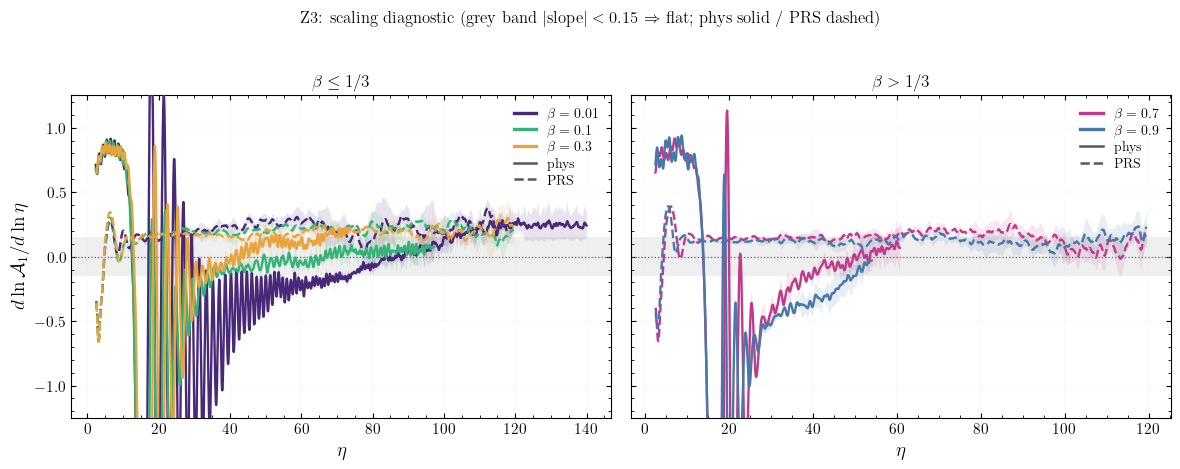

In [5]:
import pandas as pd
LATE_FRAC, SLOPE_TOL, RES_MIN = 0.40, 0.15, 2.0

def _late(x, frac=LATE_FRAC):
    x = np.asarray(x, float)
    if x.size == 0:
        return np.zeros(0, bool)
    return x >= (x[-1] - frac * (x[-1] - x[0]))

def scaling_row(beta, evo):
    x, A, sd = seed_stack(beta, evo, lambda d: area_seed(d, 'scal1'))
    d0 = first_run(beta, evo)
    src = path_src(d0['path']) if d0 is not None else '--'
    if x is None or d0 is None or not np.isfinite(A).any():
        return dict(beta=beta, evo=EVOLAB[evo], src=src, eta_max=np.nan,
                    cells_wall=np.nan, A_plateau=np.nan, A_std=np.nan,
                    slope=np.nan, verdict='no data')
    sx, ssl = log_slope(x, A)
    m = _late(sx); slope = np.nanmean(ssl[m]) if m.any() else np.nan
    mA = _late(x); A_pl = np.nanmean(A[mA])
    A_sd = np.nanmean(sd[mA]) if sd is not None else np.nan
    cw = cells_per_wall(d0)[1][-1]
    if not np.isfinite(slope):    v = 'no data'
    elif cw < RES_MIN:            v = 'under-res'
    elif abs(slope) < SLOPE_TOL:  v = 'SCALING'
    elif slope > 0:               v = 'growing'
    else:                         v = 'declining'
    return dict(beta=beta, evo=EVOLAB[evo], src=src, eta_max=round(float(x[-1]), 1),
                cells_wall=round(float(cw), 2), A_plateau=round(float(A_pl), 3),
                A_std=round(float(A_sd), 3), slope=round(float(slope), 3), verdict=v)

tbl = pd.DataFrame([scaling_row(b, e) for b in BETAS for e in EVOS])
print(f'{MODEL} adjacent-wall scaling verdict   (late window = last {int(LATE_FRAC*100)}% in eta;'
      f'  SCALING iff |slope|<{SLOPE_TOL} and cells/wall>={RES_MIN})')
print(tbl.to_string(index=False))

# focused verdict figure: the scaling slope with the "flat" band shaded
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
for k, (ax, (glab, bs)) in enumerate(zip(axes, GROUPS)):
    ax.axhspan(-SLOPE_TOL, SLOPE_TOL, color='0.5', alpha=0.12, lw=0, zorder=0)
    ax.axhline(0.0, color='0.4', lw=0.9, ls=':')
    plot_betas(ax, bs, lambda d: slope_seed(d, 'scal1'))
    ax.set_ylim(-1.25, 1.25)
    paper_ax(ax, ylabel=(r'$d\ln\mathcal{A}_1/d\ln\eta$' if k == 0 else ''), title=glab)
    beta_legend(ax, bs)
fig.suptitle(rf'{MODEL}: scaling diagnostic  (grey band $|$slope$|<{SLOPE_TOL}$ $\Rightarrow$ flat;'
             r' phys solid / PRS dashed)', y=1.02, fontsize=12)
fig.tight_layout(); plt.show()

# Part I --- Headline physics

## 1. Cosmology & symmetry breaking (sanity)

$a=1+\eta$ (radiation, $H_0/\mu=1$) for both phys and PRS; the field rolls to the
broken minimum $\langle h^2\rangle+\langle a^2\rangle\to v^2=1$.

/tmp/ipykernel_849736/4140786647.py:73: RuntimeWarning: Mean of empty slice
  Y = np.vstack(ys); return xref, np.nanmean(Y, 0), np.nanstd(Y, 0)
/mt/home/dpasari/.local/lib/python3.9/site-packages/numpy/lib/_nanfunctions_impl.py:1887: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)
/mt/home/dpasari/.local/lib/python3.9/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


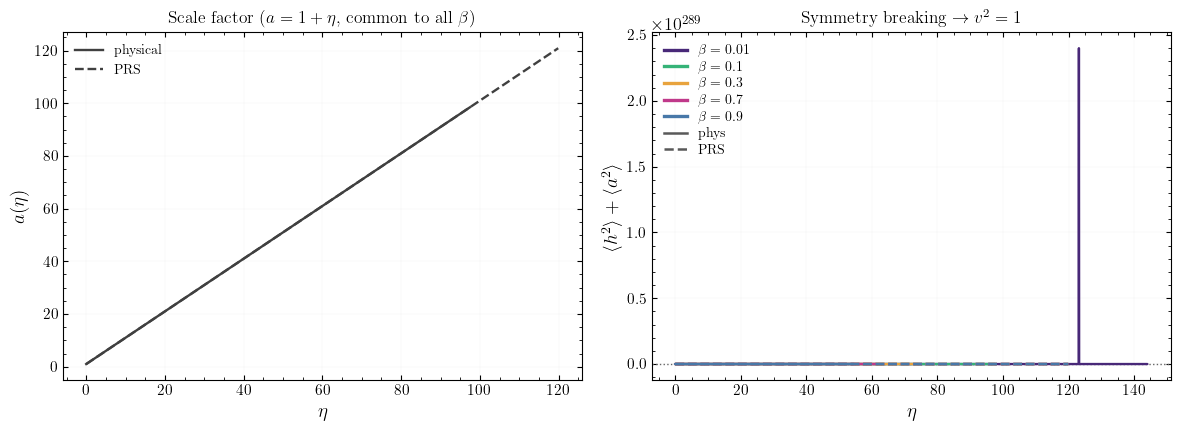

In [6]:
def phi2(d):
    s0, s1 = d['scalar0'], d['scalar1']
    if s0 is None or s1 is None:
        return d['energies']['eta'], np.full_like(d['energies']['eta'], np.nan)
    return s0['eta'], s0['mean2'] + np.interp(s0['eta'], s1['eta'], s1['mean2'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ax = axes[0]
for e in EVOS:
    d = first_run(0.1, e)
    if d:
        ax.plot(d['scale_factor']['eta'], d['scale_factor']['a'], color='0.25', ls=LS[e], lw=LW,
                label=EVOLAB[e])
ax.legend(fontsize=10, frameon=False)
paper_ax(ax, ylabel=r'$a(\eta)$', title=r'Scale factor ($a=1+\eta$, common to all $\beta$)')

ax = axes[1]
plot_betas(ax, BETAS, phi2)
ax.axhline(1.0, color='0.4', ls=':', lw=1.0)
paper_ax(ax, ylabel=r'$\langle h^2\rangle+\langle a^2\rangle$', title=r'Symmetry breaking $\to v^2=1$')
beta_legend(ax, BETAS)
fig.tight_layout(); plt.show()

## 2. Adjacent (headline) wall area $\mathcal{A}_1=\mathrm{scal}_1/(2aH)$

The physically meaningful comparison is each model's **plateau height** read where it is
simultaneously at scaling (slope $\approx0$, &sect;3) and resolved (cells/wall $\gtrsim2$,
&sect;5).  Physical passes through a transient overshoot before settling toward PRS.

/tmp/ipykernel_849736/4140786647.py:73: RuntimeWarning: Mean of empty slice
  Y = np.vstack(ys); return xref, np.nanmean(Y, 0), np.nanstd(Y, 0)


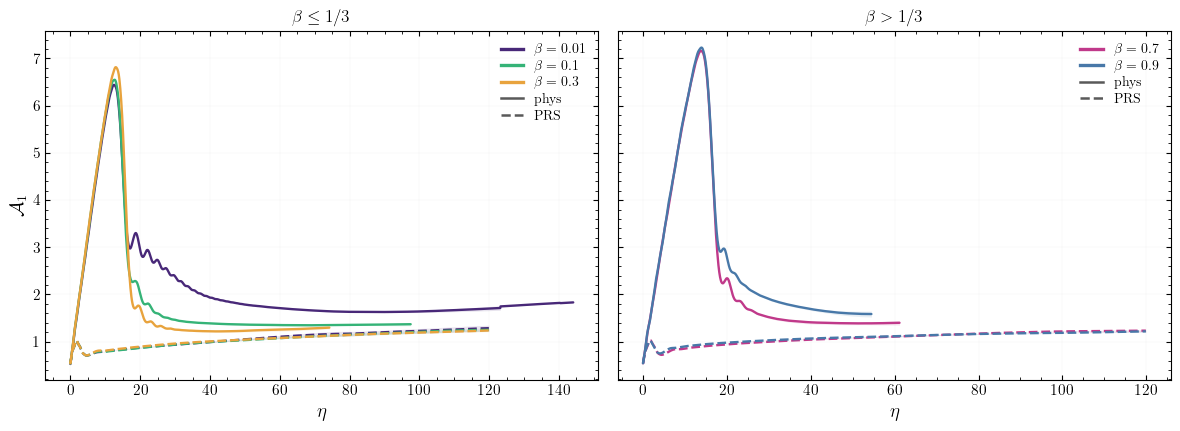

In [7]:
fig_lowhigh(lambda d: area_seed(d, 'scal1'), r'$\mathcal{A}_1$')

## 3. Scaling diagnostic: $d\ln\mathcal{A}/d\ln\eta$

Scaling ($\mathcal{A}=$const) $\Rightarrow$ slope $\to0$ (dotted line).  Sliding log-log fit.


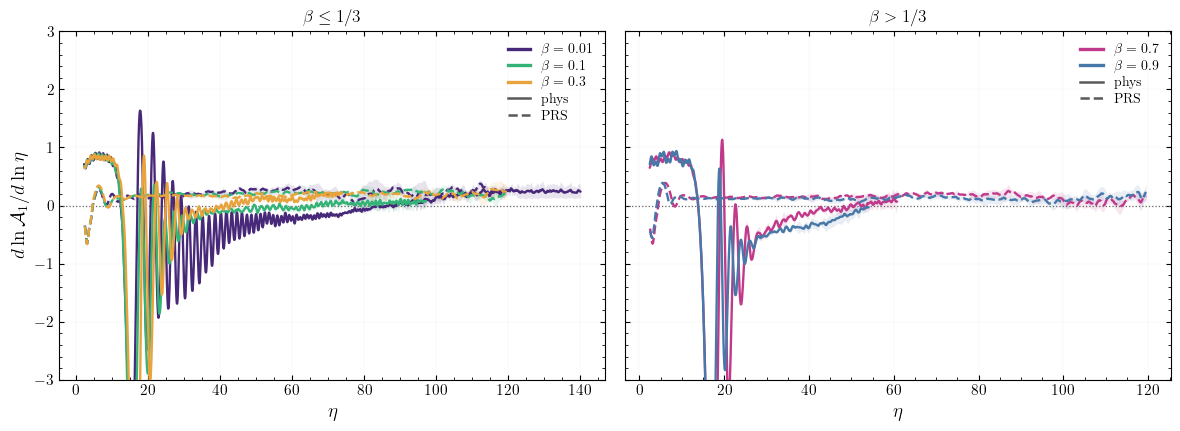

In [8]:
fig_lowhigh(lambda d: slope_seed(d, 'scal1'), r'$d\ln\mathcal{A}_1/d\ln\eta$',
            hline=0.0, sharey=True, ylim=(-3, 3))

## 4. Plateau $\mathcal{A}_1$ ratio (phys/PRS) &mdash; **PROVISIONAL**

> Runs are early/live; physical $\mathcal{A}_1$ is still in its transient overshoot, so the
> auto-window ratio is transient-dominated, **not** a converged plateau (finished-run $Z_4$
> junction gap $\approx1.28$).  Trust &sect;2&ndash;3 until the runs reach their late plateau.

PROVISIONAL (live, transient-dominated -- not a converged plateau):
  beta   A1_phys    A1_PRS   ratio
----------------------------------
  0.01     2.112     1.218   1.735
   0.1     1.896     1.194   1.587
   0.3     1.974     1.181   1.671
   0.7     2.399     1.203   1.995
   0.9     2.759     1.184   2.331


/tmp/ipykernel_849736/4140786647.py:73: RuntimeWarning: Mean of empty slice
  Y = np.vstack(ys); return xref, np.nanmean(Y, 0), np.nanstd(Y, 0)


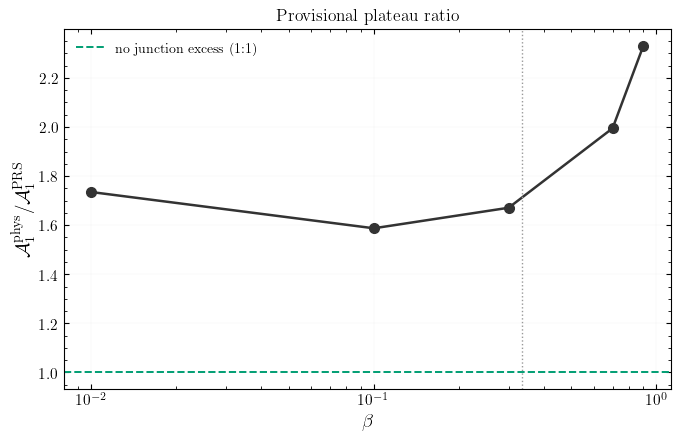

In [9]:
def plateau_phys(b):
    x, y, _ = seed_stack(b, 'phys', lambda d: area_seed(d, 'scal1'))
    if x is None:
        return np.nan
    d0 = first_run(b, 'phys')
    if d0 is None:
        return np.nan
    ex, cw = cells_per_wall(d0); cwx = np.interp(x, ex, cw)
    m = (cwx >= 2.0) & np.isfinite(y)
    if m.sum() < 2:
        m = np.isfinite(y)
    return np.nanmean(y[m])

def plateau_prs(b):
    x, y, _ = seed_stack(b, 'prs', lambda d: area_seed(d, 'scal1'))
    if x is None:
        return np.nan
    m = (x >= x.max()*0.6) & np.isfinite(y)
    return np.nanmean(y[m]) if m.sum() else np.nan

print("PROVISIONAL (live, transient-dominated -- not a converged plateau):")
print(f"{'beta':>6} {'A1_phys':>9} {'A1_PRS':>9} {'ratio':>7}"); print('-'*34)
ratios = {}
for b in BETAS:
    pp, pr = plateau_phys(b), plateau_prs(b); ratios[b] = pp/pr if pr else np.nan
    print(f"{b:>6} {pp:>9.3f} {pr:>9.3f} {ratios[b]:>7.3f}")

fig, ax = plt.subplots(figsize=(7, 4.6))
bs = [b for b in BETAS if np.isfinite(ratios[b])]
ax.plot(bs, [ratios[b] for b in bs], 'o-', color='#333333', lw=1.8, ms=7)
ax.axhline(1.0, color='#009E73', ls='--', lw=1.4, label='no junction excess (1:1)')
ax.axvline(1/3, color='0.6', ls=':', lw=1.0)
ax.set_xscale('log')
paper_ax(ax, xlabel=r'$\beta$', ylabel=r'$\mathcal{A}_1^{\rm phys}/\mathcal{A}_1^{\rm PRS}$',
         title='Provisional plateau ratio')
ax.legend(fontsize=10, frameon=False)
fig.tight_layout(); plt.show()

## 5. Junction string scaling $\xi=\mathrm{Jstr\_len}/(2aH^2)$

Codim-2 $\theta$-winding string pierced by the wall network (two horizon powers).

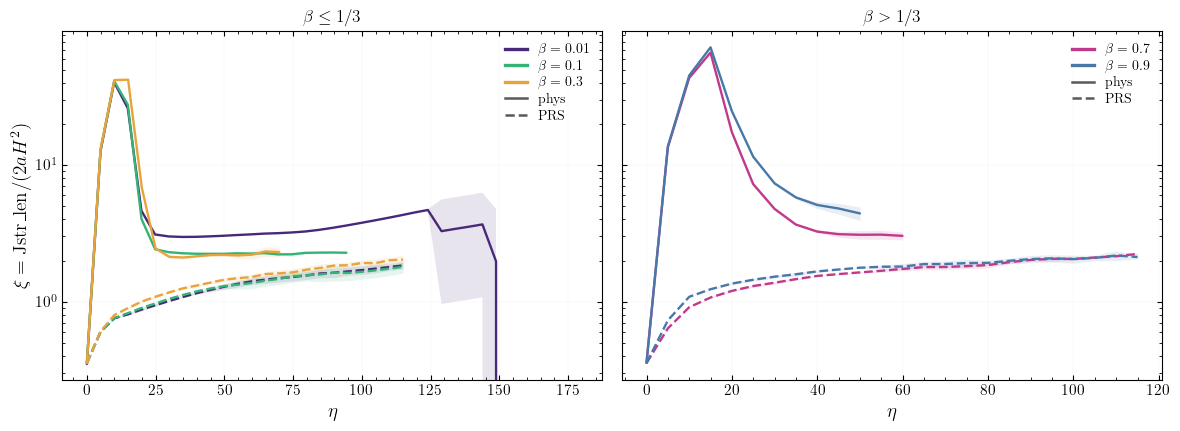

In [10]:
fig_lowhigh(xi_seed, r'$\xi=\mathrm{Jstr\_len}/(2aH^2)$', ylog=True, sharey=True)

## 6. Wall RMS 3-velocity $v^2=v^2\gamma^2/(1+v^2\gamma^2)$

$v^2\gamma^2=\mathrm{KE}/V$ on wall sites (potential cutoff $\alpha=0.4$); **PRS $\times a^2$**
(conformal-time normalisation; physical unchanged).  Early dip = random IC before walls form.

/tmp/ipykernel_849736/4140786647.py:73: RuntimeWarning: Mean of empty slice
  Y = np.vstack(ys); return xref, np.nanmean(Y, 0), np.nanstd(Y, 0)


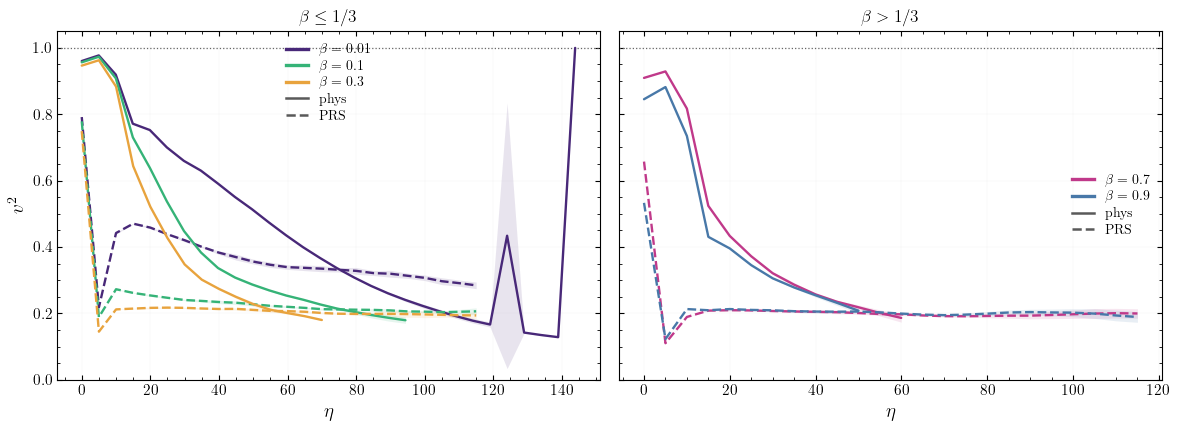

In [11]:
fig_lowhigh(lambda d: v2_seed(d, 'A04'), r'$v^2$', hline=1.0, sharey=True, ylim=(0, 1.05))

## 7. Resolution self-report --- cells/wall & cells/core

Physical walls/cores thin $\propto1/a$ (sub-grid at late $\eta$); PRS frozen ($a=1$).
cells/wall $=\bar\delta_{\rm adj}/(\mu a\,dx)$; cells/core $=(2/m_h)/(a\,dx)$.  Dotted lines =
2 cells (orange) and Nyquist (grey).

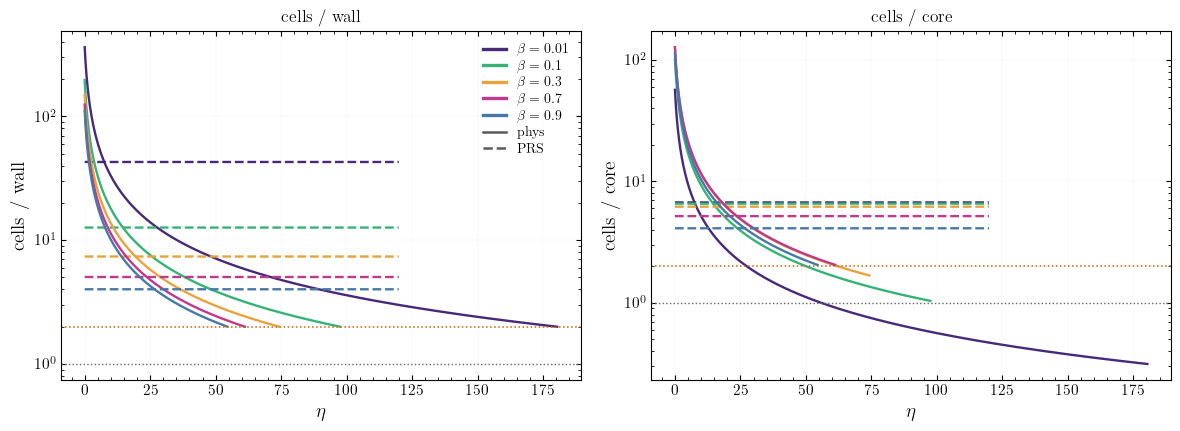

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, fn, lab in [(axes[0], cells_per_wall, 'cells / wall'),
                    (axes[1], cells_per_core, 'cells / core')]:
    for b in BETAS:
        for e in EVOS:
            d0 = first_run(b, e)
            if d0 is None:
                continue
            x, y = fn(d0)
            ax.plot(x, y, color=BCOL[b], ls=LS[e], lw=LW)
    ax.axhline(2.0, color='#D55E00', ls=':', lw=1.1); ax.axhline(1.0, color='0.4', ls=':', lw=1.0)
    ax.set_yscale('log'); paper_ax(ax, ylabel=lab, title=lab)
beta_legend(axes[0], BETAS)
fig.tight_layout(); plt.show()

# Part II --- Supporting diagnostics

## A1. Energy components (representative $\beta=0.1$ | $0.9$)

Kinetic, gradient, potential and total energy (seed s01), physical solid / PRS dashed.

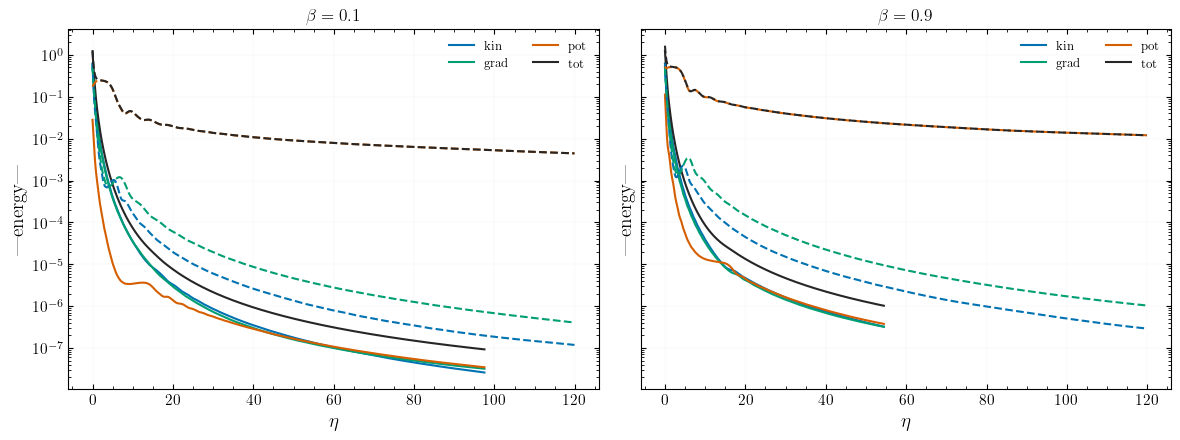

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
ecol = {'kin': '#0072B2', 'grad': '#009E73', 'pot': '#D55E00', 'tot': '0.15'}
for ax, b in zip(axes, REPB):
    for e in EVOS:
        d = first_run(b, e)
        if d is None:
            continue
        en = d['energies']
        comp = {'kin': en['Ek_h'] + en['Ek_a'], 'grad': en['Eg_h'] + en['Eg_a'],
                'pot': en['V0'] + en['V1'] + en['V2'], 'tot': en['Etot']}
        for k, c in ecol.items():
            ax.plot(en['eta'], np.abs(comp[k]), color=c, ls=LS[e], lw=1.5,
                    label=(k if e == 'phys' else None))
    ax.set_yscale('log'); paper_ax(ax, ylabel='|energy|', title=rf'$\beta={b}$')
    ax.legend(fontsize=9, frameon=False, ncol=2)
fig.tight_layout(); plt.show()

## A2. Field means $\langle h\rangle$, $\langle a\rangle$

$\langle h\rangle\to v$, $\langle a\rangle\to0$ (the selected vacuum).

/tmp/ipykernel_849736/4140786647.py:73: RuntimeWarning: Mean of empty slice
  Y = np.vstack(ys); return xref, np.nanmean(Y, 0), np.nanstd(Y, 0)


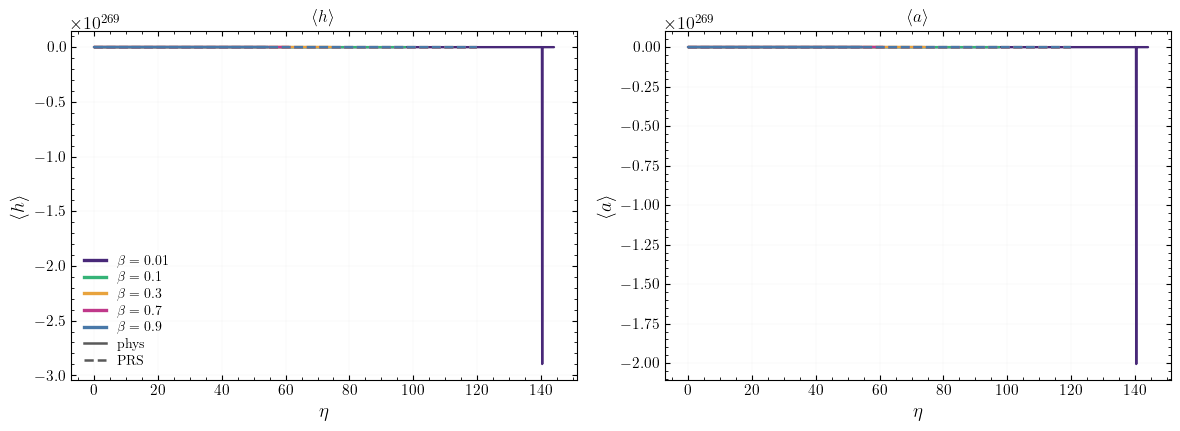

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)
mh = lambda d: (d['scalar0']['eta'], d['scalar0']['mean']) if d['scalar0'] else (np.array([]), np.array([]))
ma = lambda d: (d['scalar1']['eta'], d['scalar1']['mean']) if d['scalar1'] else (np.array([]), np.array([]))
plot_betas(axes[0], BETAS, mh); paper_ax(axes[0], ylabel=r'$\langle h\rangle$', title=r'$\langle h\rangle$')
plot_betas(axes[1], BETAS, ma); paper_ax(axes[1], ylabel=r'$\langle a\rangle$', title=r'$\langle a\rangle$')
beta_legend(axes[0], BETAS)
fig.tight_layout(); plt.show()

## A3. Field RMS $\sqrt{\langle h^2\rangle}$, $\sqrt{\langle a^2\rangle}$

/tmp/ipykernel_849736/4140786647.py:73: RuntimeWarning: Mean of empty slice
  Y = np.vstack(ys); return xref, np.nanmean(Y, 0), np.nanstd(Y, 0)


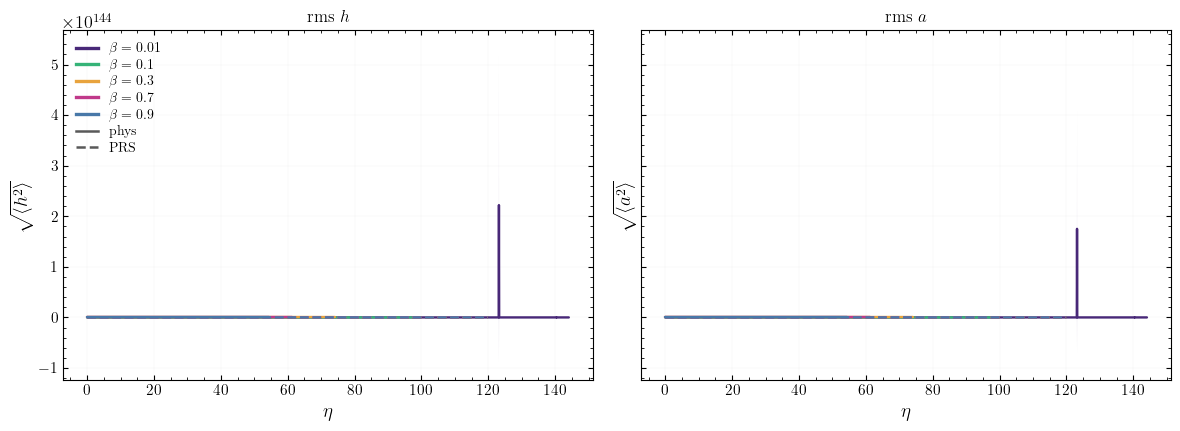

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True, sharey=True)
rh = lambda d: (d['scalar0']['eta'], np.sqrt(d['scalar0']['mean2'])) if d['scalar0'] else (np.array([]), np.array([]))
ra = lambda d: (d['scalar1']['eta'], np.sqrt(d['scalar1']['mean2'])) if d['scalar1'] else (np.array([]), np.array([]))
plot_betas(axes[0], BETAS, rh); paper_ax(axes[0], ylabel=r'$\sqrt{\langle h^2\rangle}$', title=r'rms $h$')
plot_betas(axes[1], BETAS, ra); paper_ax(axes[1], ylabel=r'$\sqrt{\langle a^2\rangle}$', title=r'rms $a$')
beta_legend(axes[0], BETAS)
fig.tight_layout(); plt.show()

## A4. Field power spectra $|h_k|^2$ (representative $\beta=0.1$ | $0.9$)

Successive output times (light $\to$ dark); physical (blue) carries more power toward
Nyquist (dotted) at late times than PRS (orange).

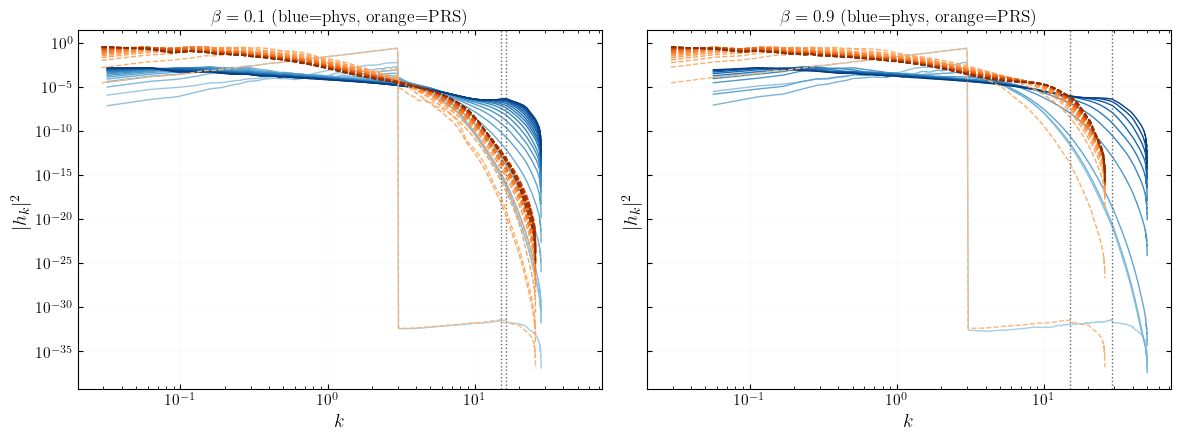

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharex=True, sharey=True)
for ax, b in zip(axes, REPB):
    for e, base in (('phys', plt.cm.Blues), ('prs', plt.cm.Oranges)):
        d = first_run(b, e)
        if d is None or d['spectra'] is None:
            continue
        inf = d['infos']; kny = np.pi/(inf.get('lSide', 1)/inf.get('N', 1024))
        blks = d['spectra']['blocks']; cols = base(np.linspace(0.35, 0.95, max(len(blks), 1)))
        for j, blk in enumerate(blks):
            if blk.ndim == 2 and blk.shape[1] >= 2:
                ax.loglog(blk[:, 0], blk[:, 1], color=cols[j], lw=1.0, ls=LS[e])
        ax.axvline(kny, color='0.4', ls=':', lw=1.0)
    paper_ax(ax, xlabel=r'$k$', ylabel=r'$|h_k|^2$', title=rf'$\beta={b}$ (blue=phys, orange=PRS)')
fig.tight_layout(); plt.show()

## A5. $v^2\gamma^2=\mathrm{KE}/V$ (the raw velocity ratio; PRS $\times a^2$)

/tmp/ipykernel_849736/4140786647.py:73: RuntimeWarning: Mean of empty slice
  Y = np.vstack(ys); return xref, np.nanmean(Y, 0), np.nanstd(Y, 0)


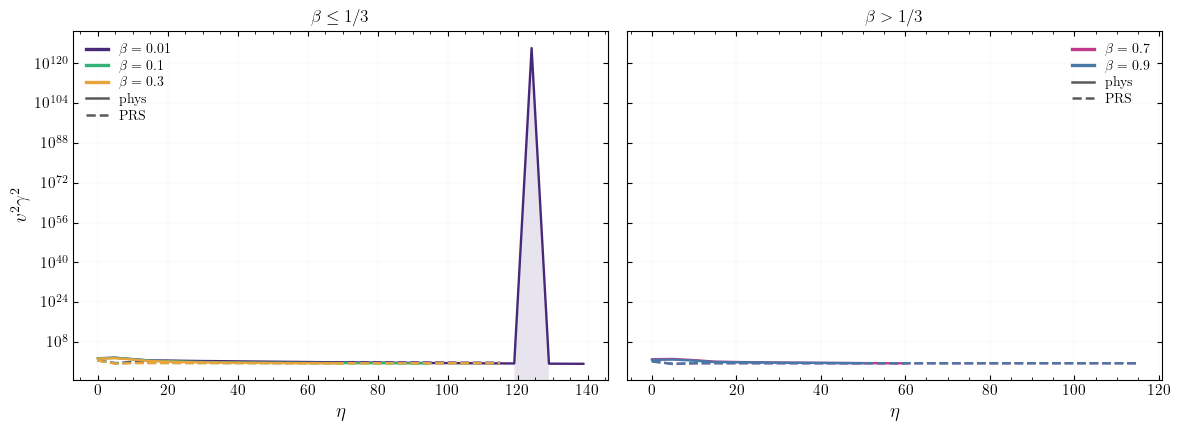

In [17]:
fig_lowhigh(lambda d: v2g2_seed(d, 'A04'), r'$v^2\gamma^2$', ylog=True, sharey=True)

## A6. Velocity cutoff robustness $\alpha\in\{0.2,0.4,0.6\}$ (rep $\beta=0.1$ | $0.9$)

$v^2$ should be weakly sensitive to the wall-site mask cutoff.  PRS carries $\times a^2$.

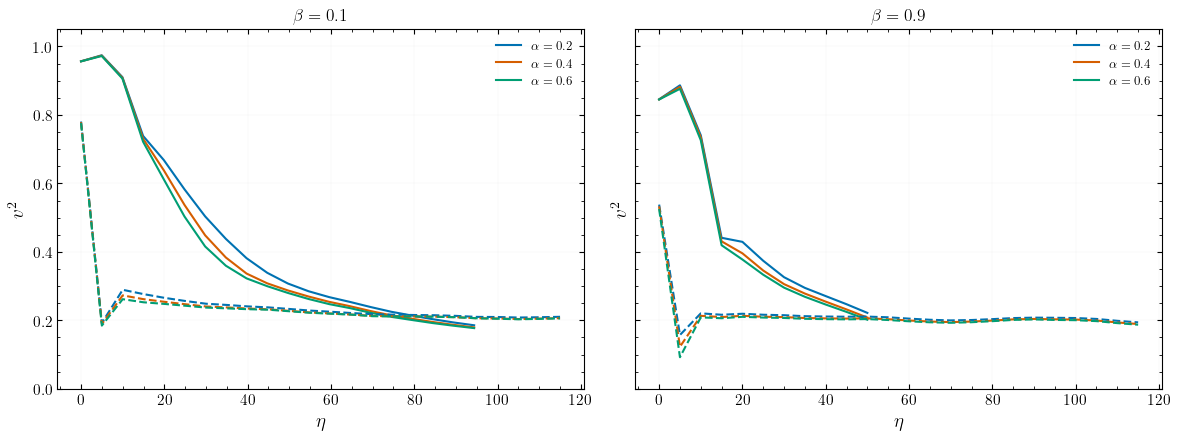

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
cutc = {'A02': '#0072B2', 'A04': '#D55E00', 'A06': '#009E73'}
for ax, b in zip(axes, REPB):
    for e in EVOS:
        for cut in ('A02', 'A04', 'A06'):
            x, m, sd = seed_stack(b, e, lambda d, c=cut: v2_seed(d, c))
            if x is not None and len(x):
                ax.plot(x, m, color=cutc[cut], ls=LS[e], lw=1.5,
                        label=(rf'$\alpha={float(cut[1:])/10:.1f}$' if e == 'phys' else None))
    ax.set_ylim(0, 1.05); paper_ax(ax, ylabel=r'$v^2$', title=rf'$\beta={b}$')
    ax.legend(fontsize=9, frameon=False)
fig.tight_layout(); plt.show()

## A7. Raw string counters & junction cores

`Jstr_cnt` (raw pierced faces), `Jstr_w2` ($|w|\ge2$ faces), `Jstr_signed` ($\approx0$ closure
check), `Jcore_cnt` ($|\Phi|<0.3v$ core sites).

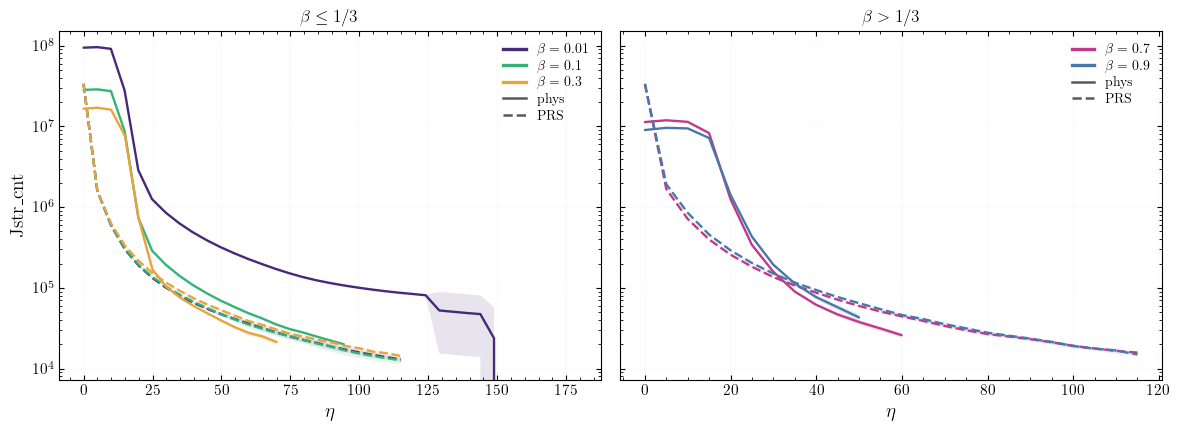

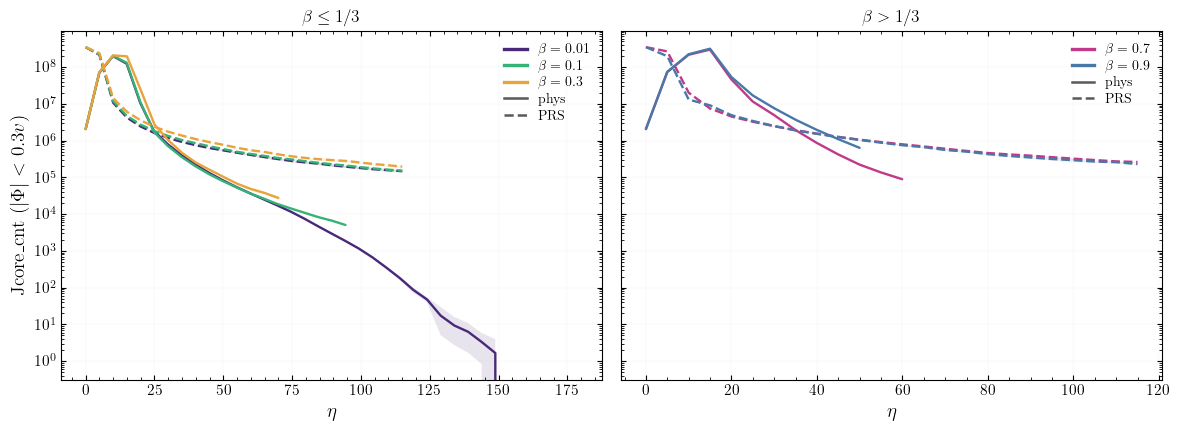

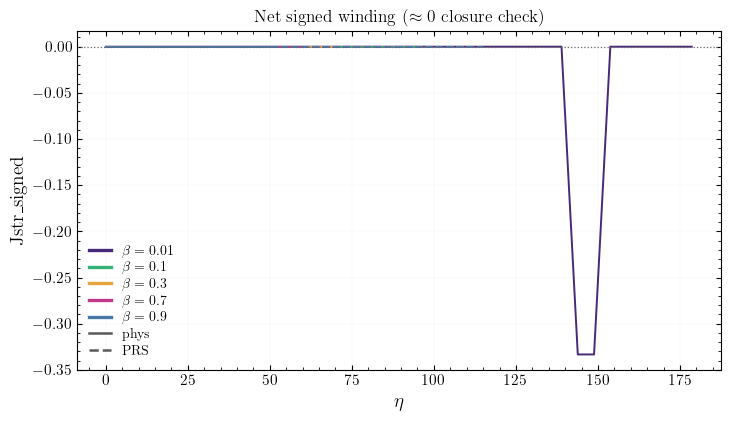

In [19]:
fig_lowhigh(wdcol('Jstr_cnt'), r'Jstr\_cnt', ylog=True, sharey=True)
fig_lowhigh(wdcol('Jcore_cnt'), r'Jcore\_cnt ($|\Phi|<0.3v$)', ylog=True, sharey=True)

# closure check: net signed winding ~ 0 (single panel, all beta)
fig, ax = plt.subplots(figsize=(7.5, 4.4))
for b in BETAS:
    for e in EVOS:
        x, m, sd = seed_stack(b, e, wdcol('Jstr_signed'))
        if x is not None and len(x):
            ax.plot(x, m, color=BCOL[b], ls=LS[e], lw=1.4)
ax.axhline(0, color='0.4', lw=0.9, ls=':')
paper_ax(ax, ylabel=r'Jstr\_signed', title=r'Net signed winding ($\approx0$ closure check)')
beta_legend(ax, BETAS)
fig.tight_layout(); plt.show()

## Summary table

In [20]:
def late_mean(x, y, frac=0.5):
    if x is None or not len(x):
        return np.nan
    m = np.isfinite(y) & (x >= x.max()*frac)
    return np.nanmean(y[m]) if m.sum() else np.nan

hdr = f"{'beta':>6} {'A1p_end':>8} {'A1r_end':>8} {'ratio':>6} {'v2_phys':>8} {'v2_prs':>8} {'cw_end':>7} {'cc_end':>7}"
print(hdr); print('-'*len(hdr))
for b in BETAS:
    xp, ap, _ = seed_stack(b, 'phys', lambda d: area_seed(d, 'scal1'))
    xr, ar, _ = seed_stack(b, 'prs',  lambda d: area_seed(d, 'scal1'))
    a1p = ap[-1] if ap is not None else np.nan
    a1r = ar[-1] if ar is not None else np.nan
    xvp, vp, _ = seed_stack(b, 'phys', lambda d: v2_seed(d, 'A04'))
    xvr, vr, _ = seed_stack(b, 'prs',  lambda d: v2_seed(d, 'A04'))
    d0 = first_run(b, 'phys')
    cw = cells_per_wall(d0)[1][-1] if d0 is not None else np.nan
    cc = cells_per_core(d0)[1][-1] if d0 is not None else np.nan
    print(f"{b:>6} {a1p:>8.3f} {a1r:>8.3f} {a1p/a1r if a1r else np.nan:>6.2f} "
          f"{late_mean(xvp, vp):>8.3f} {late_mean(xvr, vr):>8.3f} {cw:>7.2f} {cc:>7.2f}")

  beta  A1p_end  A1r_end  ratio  v2_phys   v2_prs  cw_end  cc_end
-----------------------------------------------------------------
  0.01      nan    1.286    nan    0.276    0.317    2.00    0.31
   0.1    1.370    1.252   1.09    0.226    0.210    2.00    1.04
   0.3    1.298    1.238   1.05    0.230    0.199    2.00    1.68
   0.7    1.400    1.234   1.13    0.244    0.196    2.00    2.06
   0.9    1.586    1.219   1.30    0.256    0.198    2.00    2.05


/tmp/ipykernel_849736/4140786647.py:73: RuntimeWarning: Mean of empty slice
  Y = np.vstack(ys); return xref, np.nanmean(Y, 0), np.nanstd(Y, 0)
